In [1]:
!mamba install pandas matplotlib

mambajs 0.19.13

Specs: xeus-python, numpy, matplotlib, pillow, ipywidgets>=8.1.6, ipyleaflet, scipy, pandas
Channels: emscripten-forge, conda-forge

Solving environment...
Solving took 0.3340999999996275 seconds
  Name                          Version                       Build                         Channel                       
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
+ pandas                        3.0.2                         np22py313h9d9dc1e_0           emscripten-forge              
+ python-tzdata                 2026.2                        pyhd8ed1ab_0                  conda-forge                   
- pip                           25.3                          pyh145f28c_0                  conda-forge                   


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv('100_execution_time.csv')
df.head()

,location_id,scenario_counter,x,y,global_time,scene_sampling_time,semantic_scene_construction_time,condition_wise_rendering_time,pipeline_time
0,0,283169,1207.286887,-335.324057,34.154359,0.000374,5.228785,22.451330,27.680494
1,1,1085115,1259.077056,-400.041021,64.644228,0.000290,3.776643,23.165917,26.942854
2,2,822340,-1061.683327,-687.016475,97.427306,0.000302,7.437150,22.123752,29.561209
3,3,2671938,1150.345255,-1969.991153,136.933032,0.000351,11.818029,24.388873,36.207262
4,4,26157,-916.957043,602.162912,169.935379,0.000352,6.141361,22.982146,29.123867


In [4]:

global_per_location = []
prev_global = None

for i, row in df.iterrows():
    current_global = row["global_time"]
    loc_id = row["location_id"]

    if loc_id == 0 or prev_global is None:
        global_per_location.append(current_global)
    else:
        global_per_location.append(current_global - prev_global)

    prev_global = current_global

df["global_time_per_location"] = global_per_location
df["location_index"] = np.arange(len(df))


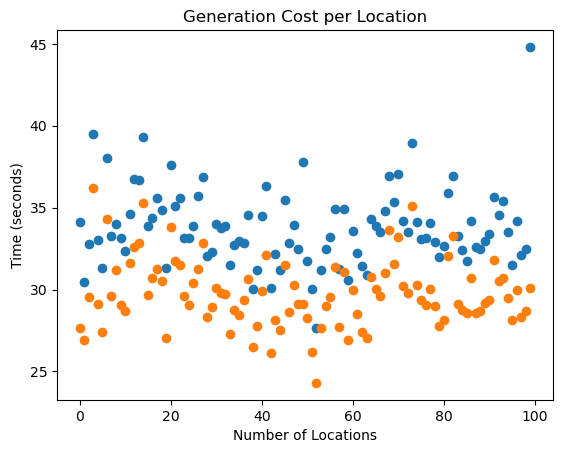

In [5]:

plt.figure()
plt.scatter(df["location_index"], df["global_time_per_location"])
plt.scatter(df["location_index"], df["pipeline_time"])
plt.xlabel("Number of Locations")
plt.ylabel("Time (seconds)")
plt.title("Generation Cost per Location")
plt.show()


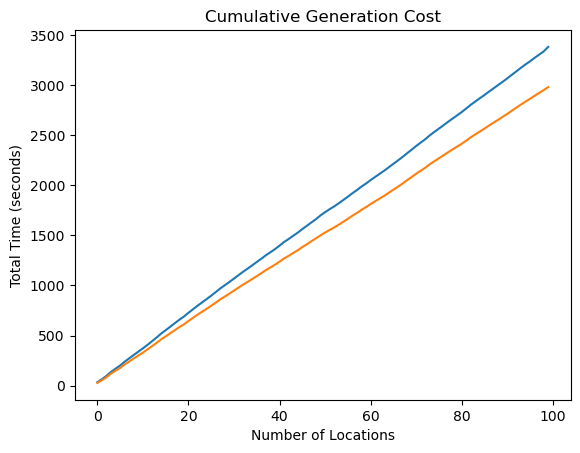

In [6]:

df["global_cumulative"] = df["global_time_per_location"].cumsum()
df["pipeline_cumulative"] = df["pipeline_time"].cumsum()

plt.figure()
plt.plot(df["location_index"], df["global_cumulative"])
plt.plot(df["location_index"], df["pipeline_cumulative"])
plt.xlabel("Number of Locations")
plt.ylabel("Total Time (seconds)")
plt.title("Cumulative Generation Cost")
plt.show()
